# Hill Climbing 爬山算法

## 本 Notebook 的教学目标

1. 理解该算法的搜索直觉。
2. 使用一个经典二维优化问题完成从零实现。
3. 通过可视化观察算法如何移动、如何收敛、可能会遇到什么问题。
4. 通过多次运行和参数实验建立更稳固的算法直觉。

## 实验问题

本实验使用 **Himmelblau 函数**。它有多个局部最优点，非常适合演示爬山算法容易陷入局部最优这一核心现象。

在教学上，二维问题有一个明显优势：**我们可以直接把搜索轨迹画出来**。这比只看一串数值更适合课堂演示。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一图表风格，保证讲课时图表更清晰。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 本项目统一使用二维测试函数，这样可以把搜索轨迹直接画在等高线上。

def make_grid(bounds, step=250):
    xs = np.linspace(bounds[0, 0], bounds[0, 1], step)
    ys = np.linspace(bounds[1, 0], bounds[1, 1], step)
    xx, yy = np.meshgrid(xs, ys)
    return xs, ys, xx, yy


def evaluate_on_grid(objective, bounds, step=250):
    xs, ys, xx, yy = make_grid(bounds, step=step)
    zz = np.vectorize(lambda a, b: objective(np.array([a, b])))(xx, yy)
    return xs, ys, xx, yy, zz


def plot_contour_with_trace(objective, bounds, trace, title, levels=40):
    xs, ys, xx, yy, zz = evaluate_on_grid(objective, bounds)
    plt.figure(figsize=(9, 7))
    contour = plt.contourf(xx, yy, zz, levels=levels, cmap='viridis')
    plt.colorbar(contour, label='Objective value')

    trace = np.array(trace)
    plt.plot(trace[:, 0], trace[:, 1], color='white', lw=2, alpha=0.9, label='Search trace')
    plt.scatter(trace[:, 0], trace[:, 1], c=np.arange(len(trace)), cmap='coolwarm', s=40, edgecolor='black')
    plt.scatter(trace[0, 0], trace[0, 1], color='gold', s=120, marker='o', edgecolor='black', label='Start')
    plt.scatter(trace[-1, 0], trace[-1, 1], color='red', s=160, marker='*', edgecolor='black', label='End / Best')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# Himmelblau 函数有多个低谷，因此很适合作为局部搜索演示问题。
def objective(point):
    x, y = point
    return (x ** 2 + y - 11) ** 2 + (x + y ** 2 - 7) ** 2

bounds = np.array([[-6, 6], [-6, 6]], dtype=float)

## 算法直觉

核心思想：每一步只查看当前点附近的一批候选解，然后贪心地走向更优解。如果附近没有更优解，就停止搜索。

为了让课堂节奏更清楚，Notebook 里的实现会优先追求**可读性**，而不是极端性能优化。

In [2]:
# 这是标准的随机邻域爬山算法。
def hill_climbing(objective, bounds, n_steps=80, step_size=0.35, n_neighbors=30, seed=0):
    rng = np.random.default_rng(seed)

    # 随机初始化一个起点。
    current = rng.uniform(bounds[:, 0], bounds[:, 1])
    current_score = objective(current)

    best = current.copy()
    best_score = current_score
    trace = [current.copy()]
    scores = [current_score]

    for _ in range(n_steps):
        # 在当前点附近采样多个邻居，再选出其中最好的那个。
        candidates = current + rng.normal(0, step_size, size=(n_neighbors, len(current)))
        candidates = np.clip(candidates, bounds[:, 0], bounds[:, 1])
        candidate_scores = np.apply_along_axis(objective, 1, candidates)
        best_idx = int(np.argmin(candidate_scores))

        # 只有出现严格改进时才移动，这体现了“贪心上山”的思想。
        if candidate_scores[best_idx] < current_score:
            current = candidates[best_idx]
            current_score = float(candidate_scores[best_idx])
            trace.append(current.copy())
            scores.append(current_score)

            if current_score < best_score:
                best = current.copy()
                best_score = current_score
        else:
            break

    return {
        'best': best,
        'best_score': best_score,
        'trace': np.array(trace),
        'scores': np.array(scores),
    }

## 单次实验演示

下面先运行一次实验，重点观察两件事：

1. 搜索轨迹是否平滑、是否容易停在局部区域。
2. 目标值是否快速下降，以及下降到什么程度后开始停滞。

best point: [-2.8923  3.1473]
best score: 0.262722


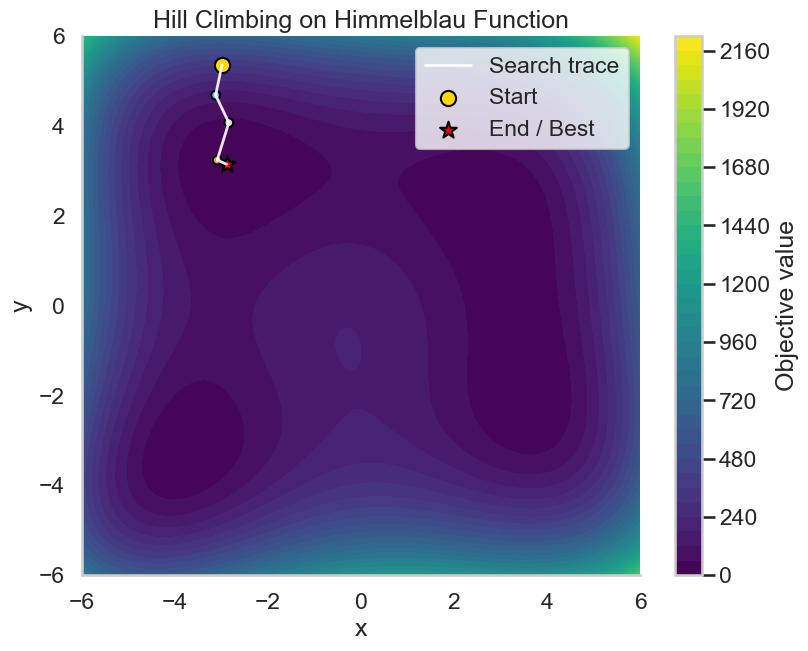

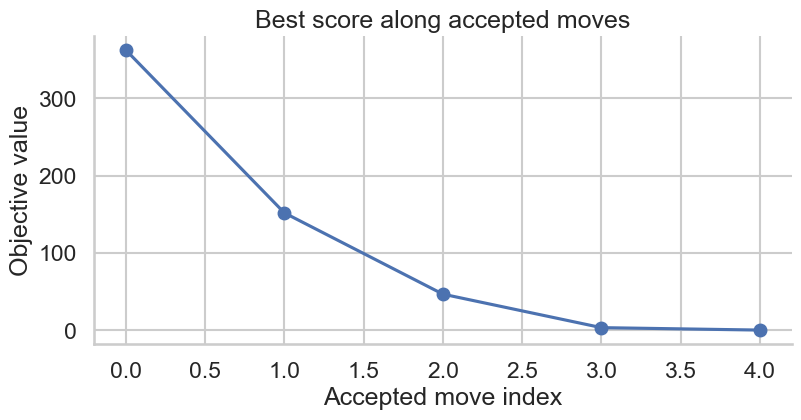

In [3]:
result = hill_climbing(objective, bounds, seed=12)
print('best point:', np.round(result['best'], 4))
print('best score:', round(float(result['best_score']), 6))

plot_contour_with_trace(
    objective,
    bounds,
    result['trace'],
    title='Hill Climbing on Himmelblau Function',
)

plt.figure(figsize=(9, 4))
plt.plot(result['scores'], marker='o')
plt.title('Best score along accepted moves')
plt.xlabel('Accepted move index')
plt.ylabel('Objective value')
plt.show()

## 多次运行与参数分析

单次实验只能告诉我们“这一次发生了什么”，但讲课时更重要的是说明：

1. 算法是否稳定。
2. 算法是否依赖初始条件。
3. 关键参数变化后，会如何影响最终表现。

,Hill Climbing statistics
best,0.000903
mean,0.096296
worst,0.334362
std,0.097519


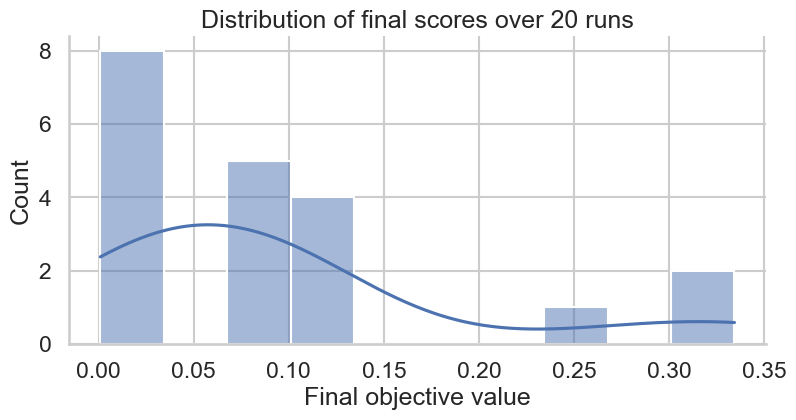

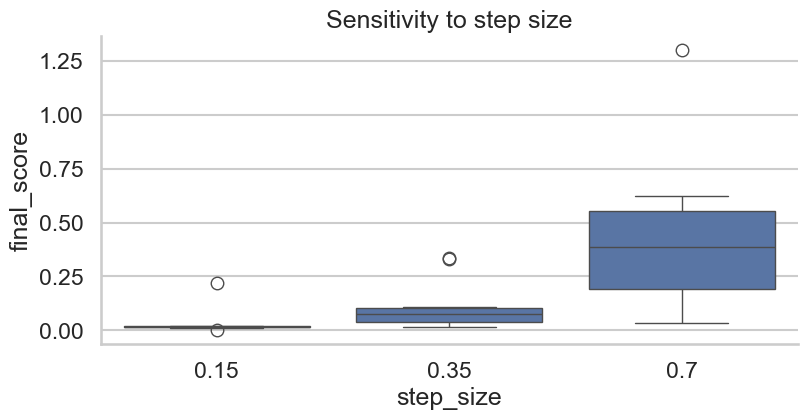

In [4]:
# 多次运行的目的是展示：爬山算法对初始点很敏感。
run_scores = []
for seed in range(20):
    run_scores.append(hill_climbing(objective, bounds, seed=seed)['best_score'])

summary = summarize_runs(run_scores)
display(summary.to_frame(name='Hill Climbing statistics'))

plt.figure(figsize=(9, 4))
sns.histplot(run_scores, bins=10, kde=True)
plt.title('Distribution of final scores over 20 runs')
plt.xlabel('Final objective value')
plt.show()

# 参数敏感性：步长过小会走得慢，步长过大又会错过精细搜索。
step_sizes = [0.15, 0.35, 0.7]
records = []
for step_size in step_sizes:
    scores = []
    for seed in range(10):
        result = hill_climbing(objective, bounds, step_size=step_size, seed=seed)
        scores.append(result['best_score'])
    records.extend({'step_size': step_size, 'final_score': score} for score in scores)

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='step_size', y='final_score')
plt.title('Sensitivity to step size')
plt.show()

## 课堂总结

讲解这一类算法时，建议把重点放在以下问题上：

1. 算法的探索能力来自哪里。
2. 算法的利用能力来自哪里。
3. 它最容易失败的场景是什么。
4. 参数变化时，算法行为为什么会改变。

把这四个问题讲清楚，学生通常就能真正建立算法直觉。